# BioBERT Factual Discriminator — MS2 Dataset

Trains a BioBERT binary classifier to distinguish **faithful** summaries (label=1) from **hallucinated** ones (label=0).
This discriminator will later be plugged into the adversarial BART training loop.

**Model:** `dmis-lab/biobert-base-cased-v1.2`  
**Dataset:** MS2 (allenai/ms2)

In [11]:
# Cell 1 — Install dependencies
!pip install transformers datasets accelerate scikit-learn -q

In [12]:
# Cell 2 — Imports and device setup
import random, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from datasets import load_dataset
from sklearn.metrics import classification_report, accuracy_score
import torch.nn.functional as F
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [13]:
# Cell 3 — Load MS2 via Parquet (bypasses loading script issue)
print('Loading MS2 from Parquet files...')

dataset = load_dataset(
    'parquet',
    data_files={
        'train':      'hf://datasets/allenai/mslr2022@refs/convert/parquet/ms2/train/*.parquet',
        'validation': 'hf://datasets/allenai/mslr2022@refs/convert/parquet/ms2/validation/*.parquet',
        'test':       'hf://datasets/allenai/mslr2022@refs/convert/parquet/ms2/test/*.parquet',
    }
)

print(dataset)
s = dataset['train'][0]
print('Keys:', list(s.keys()))
print('Abstract snippet:', str(s.get('abstract', ''))[:300])
print('Target snippet:  ', str(s.get('target', ''))[:300])

Loading MS2 from Parquet files...
DatasetDict({
    train: Dataset({
        features: ['review_id', 'pmid', 'title', 'abstract', 'target', 'background'],
        num_rows: 14188
    })
    validation: Dataset({
        features: ['review_id', 'pmid', 'title', 'abstract', 'target', 'background'],
        num_rows: 2021
    })
    test: Dataset({
        features: ['review_id', 'pmid', 'title', 'abstract', 'target', 'background'],
        num_rows: 1667
    })
})
Keys: ['review_id', 'pmid', 'title', 'abstract', 'target', 'background']
Abstract snippet: ['Although transplantation of adult bone marrow mesenchymal stem cells ( BM-MSCs ) holds promise in the treatment for pulmonary arterial hypertension ( PAH ) , the poor survival and differentiation potential of adult BM-MSCs have limited their therapeutic efficiency . Here , we compared the therapeu
Target snippet:   Conclusions SC therapy is effective for PAH in pre clinical studies .
These results may help to st and ardise pre clinical 

In [14]:
# Cell 4 — Negative sample generation (hallucination simulation)
def perturb(summary, all_summaries, strategy='random_replace'):
    if strategy == 'random_replace':
        fake = random.choice(all_summaries)
        return fake if fake != summary else summary[::-1]
    elif strategy == 'sentence_shuffle':
        sents = summary.split('. ')
        if len(sents) > 1:
            random.shuffle(sents)
            return '. '.join(sents)
        return perturb(summary, all_summaries, 'random_replace')
    elif strategy == 'word_swap':
        words = summary.split()
        other = random.choice(all_summaries).split()
        if len(words) < 4 or len(other) < 4:
            return perturb(summary, all_summaries, 'random_replace')
        n = max(1, len(words) // 5)
        for idx in random.sample(range(len(words)), min(n, len(words))):
            words[idx] = random.choice(other)
        return ' '.join(words)
    return summary

def build_dataset(split, max_samples=2000):
    records = []
    for item in split:
        # abstract is a list of strings — join all docs into one
        raw_doc = item.get('abstract') or []
        if isinstance(raw_doc, list):
            doc = ' '.join([d.strip() for d in raw_doc if d])
        else:
            doc = str(raw_doc).strip()

        # target/summary is a plain string
        summ = item.get('target') or item.get('summary') or ''
        if isinstance(summ, list):
            summ = ' '.join(summ)
        summ = summ.strip()

        if len(doc) > 50 and len(summ) > 20:
            records.append((doc, summ))
        if len(records) >= max_samples:
            break

    all_summs = [r[1] for r in records]
    strategies = ['random_replace', 'sentence_shuffle', 'word_swap']
    examples = []
    for doc, summ in records:
        examples.append({'document': doc, 'summary': summ, 'label': 1})
        fake = perturb(summ, all_summs, random.choice(strategies))
        examples.append({'document': doc, 'summary': fake, 'label': 0})
    random.shuffle(examples)
    return examples

print('Building train set...')
train_examples = build_dataset(dataset['train'], 2000)
print('Building val set...')
val_examples   = build_dataset(dataset['validation'], 400)
print(f'Train: {len(train_examples)} | Val: {len(val_examples)}')

Building train set...
Building val set...
Train: 4000 | Val: 800


In [15]:
# Cell 5 — Tokenizer and PyTorch Dataset
MODEL_NAME = 'dmis-lab/biobert-base-cased-v1.2'
MAX_LEN    = 512
BATCH_SIZE = 16

print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class DiscDataset(Dataset):
    def __init__(self, examples, tok, max_len):
        self.examples = examples
        self.tok = tok
        self.max_len = max_len
    def __len__(self):
        return len(self.examples)
    def __getitem__(self, idx):
        ex = self.examples[idx]
        enc = self.tok(
            ex['document'], ex['summary'],
            max_length=self.max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        tt = enc.get('token_type_ids', torch.zeros(1, self.max_len, dtype=torch.long))
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': tt.squeeze(0),
            'label':          torch.tensor(ex['label'], dtype=torch.long)
        }

train_ds = DiscDataset(train_examples, tokenizer, MAX_LEN)
val_ds   = DiscDataset(val_examples,   tokenizer, MAX_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Loading tokenizer: dmis-lab/biobert-base-cased-v1.2


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Train batches: 250 | Val batches: 50


In [16]:
# Cell 6 — Load BioBERT model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
).to(DEVICE)
tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {tp:,}')

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Trainable params: 108,311,810


In [17]:
# Cell 7 — Optimizer and scheduler
EPOCHS = 4
LR     = 2e-5

optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.1)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
criterion    = nn.CrossEntropyLoss()
print(f'Total steps: {total_steps} | Warmup: {warmup_steps}')

Total steps: 1000 | Warmup: 100


In [18]:
# Cell 8 — Train and evaluate functions
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, preds_all, labels_all = 0, [], []
    for step, batch in enumerate(loader):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        tt   = batch['token_type_ids'].to(device)
        lbl  = batch['label'].to(device)
        optimizer.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask, token_type_ids=tt)
        loss = criterion(out.logits, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
        preds_all.extend(torch.argmax(out.logits, 1).cpu().numpy())
        labels_all.extend(lbl.cpu().numpy())
        if (step+1) % 50 == 0:
            print(f'  Step {step+1}/{len(loader)} loss={loss.item():.4f}')
    return total_loss/len(loader), accuracy_score(labels_all, preds_all)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, preds_all, labels_all = 0, [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            tt   = batch['token_type_ids'].to(device)
            lbl  = batch['label'].to(device)
            out  = model(input_ids=ids, attention_mask=mask, token_type_ids=tt)
            total_loss += criterion(out.logits, lbl).item()
            preds_all.extend(torch.argmax(out.logits, 1).cpu().numpy())
            labels_all.extend(lbl.cpu().numpy())
    report = classification_report(labels_all, preds_all, target_names=['Hallucinated','Faithful'])
    return total_loss/len(loader), accuracy_score(labels_all, preds_all), report

In [19]:
# Cell 9 — Training loop
best_val_acc = 0
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(1, EPOCHS+1):
    print(f'\n=== Epoch {epoch}/{EPOCHS} ===')
    tl, ta = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
    vl, va, report = evaluate(model, val_loader, criterion, DEVICE)
    history['train_loss'].append(tl); history['train_acc'].append(ta)
    history['val_loss'].append(vl);   history['val_acc'].append(va)
    print(f'Train loss={tl:.4f} acc={ta:.4f}')
    print(f'Val   loss={vl:.4f} acc={va:.4f}')
    print(report)
    if va > best_val_acc:
        best_val_acc = va
        model.save_pretrained('/content/biobert_discriminator_best')
        tokenizer.save_pretrained('/content/biobert_discriminator_best')
        print(f'  New best saved! acc={best_val_acc:.4f}')

print(f'Done. Best val acc: {best_val_acc:.4f}')


=== Epoch 1/4 ===
  Step 50/250 loss=0.5077
  Step 100/250 loss=0.2941
  Step 150/250 loss=0.5576
  Step 200/250 loss=0.0454
  Step 250/250 loss=0.0410
Train loss=0.3511 acc=0.8660
Val   loss=0.2769 acc=0.9150
              precision    recall  f1-score   support

Hallucinated       0.89      0.94      0.92       400
    Faithful       0.94      0.89      0.91       400

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.91       800
weighted avg       0.92      0.92      0.91       800



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best saved! acc=0.9150

=== Epoch 2/4 ===
  Step 50/250 loss=0.5506
  Step 100/250 loss=0.0762
  Step 150/250 loss=0.5753
  Step 200/250 loss=0.0108
  Step 250/250 loss=0.0110
Train loss=0.1725 acc=0.9487
Val   loss=0.2254 acc=0.9375
              precision    recall  f1-score   support

Hallucinated       0.93      0.94      0.94       400
    Faithful       0.94      0.93      0.94       400

    accuracy                           0.94       800
   macro avg       0.94      0.94      0.94       800
weighted avg       0.94      0.94      0.94       800



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best saved! acc=0.9375

=== Epoch 3/4 ===
  Step 50/250 loss=0.0099
  Step 100/250 loss=0.0059
  Step 150/250 loss=0.0192
  Step 200/250 loss=0.0042
  Step 250/250 loss=0.0333
Train loss=0.0793 acc=0.9818
Val   loss=0.2819 acc=0.9363
              precision    recall  f1-score   support

Hallucinated       0.93      0.94      0.94       400
    Faithful       0.94      0.93      0.94       400

    accuracy                           0.94       800
   macro avg       0.94      0.94      0.94       800
weighted avg       0.94      0.94      0.94       800


=== Epoch 4/4 ===
  Step 50/250 loss=0.3146
  Step 100/250 loss=0.0038
  Step 150/250 loss=0.0028
  Step 200/250 loss=0.0042
  Step 250/250 loss=0.0030
Train loss=0.0521 acc=0.9902
Val   loss=0.3033 acc=0.9400
              precision    recall  f1-score   support

Hallucinated       0.94      0.94      0.94       400
    Faithful       0.94      0.94      0.94       400

    accuracy                           0.94       800
   m

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best saved! acc=0.9400
Done. Best val acc: 0.9400


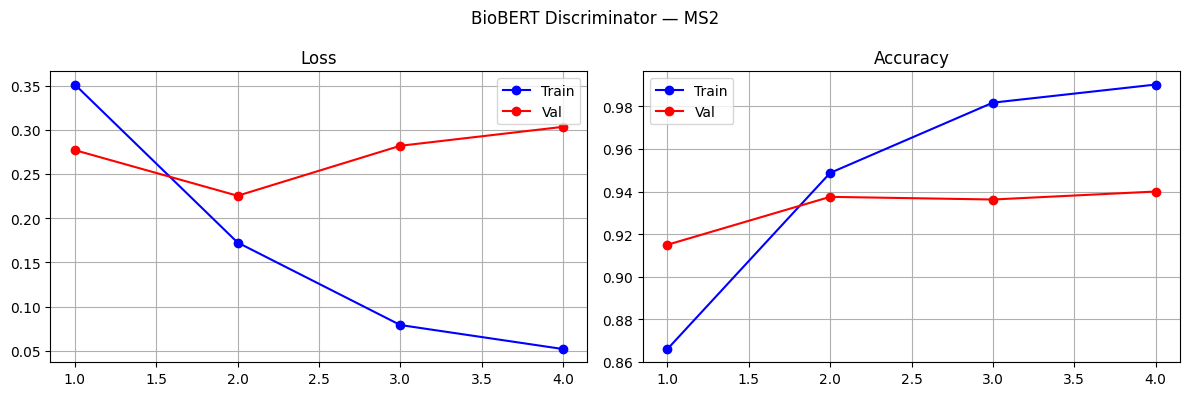

In [20]:
# Cell 10 — Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, EPOCHS+1)
axes[0].plot(ep, history['train_loss'], 'b-o', label='Train')
axes[0].plot(ep, history['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(ep, history['train_acc'], 'b-o', label='Train')
axes[1].plot(ep, history['val_acc'],   'r-o', label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('BioBERT Discriminator — MS2')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

In [22]:
# Cell 11 — Inference: score any (document, summary) pair
def load_discriminator(path='/content/biobert_discriminator_best'):
    tok = AutoTokenizer.from_pretrained(path)
    mdl = AutoModelForSequenceClassification.from_pretrained(path).to(DEVICE)
    mdl.eval()
    return tok, mdl

def score_summary(document, summary, tok, mdl, max_len=512):
    enc = tok(document, summary, max_length=max_len,
               padding='max_length', truncation=True, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(mdl(**enc).logits, dim=1)
    return probs[0][1].item()  # faithful probability

disc_tok, disc_mdl = load_discriminator()

sample    = dataset['validation'][0]
doc       = ' '.join([d.strip() for d in sample['abstract'] if d])
real_summ = sample['target']
fake_summ = 'The drug showed no effects and all patients declined rapidly.'

print(f'Real summary score: {score_summary(doc, real_summ, disc_tok, disc_mdl):.4f}')
print(f'Fake summary score: {score_summary(doc, fake_summ, disc_tok, disc_mdl):.4f}')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Real summary score: 0.9964
Fake summary score: 0.0028


In [23]:
# Cell 12 — Save to Google Drive (uncomment to use)
# from google.colab import drive
# drive.mount('/content/drive')
# import shutil
# shutil.copytree('/content/biobert_discriminator_best',
#                 '/content/drive/MyDrive/biobert_discriminator_ms2')
# print('Saved to Drive!')
print('Uncomment above cells to save model to Google Drive.')

Uncomment above cells to save model to Google Drive.
